<a href="https://colab.research.google.com/github/RM564246/machine-learning-cloud/blob/main/SilasFernandes_rm564246_fase5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objetivo
Realizar un análisis exploratorio y de clusterización en el dataset "/content/crop_yield.csv" para identificar tendencias en los rendimientos de las plantaciones y detectar posibles outliers.

## Carga e exploração inicial de dados

Carregar o dataset `crop_yield.csv` em um DataFrame de pandas e mostrar as primeiras linhas, informações gerais e estatísticas descritivas para se familiarizar com os dados.

In [1]:
import pandas as pd

# Carregar o dataset
df = pd.read_csv('/content/crop_yield.csv')

# Mostrar as primeiras linhas
print("Primeiras 5 linhas do dataset:")
display(df.head())

# Mostrar informações gerais
print("\nInformações gerais do dataset:")
display(df.info())

# Mostrar estatísticas descritivas
print("\nEstatísticas descritivas do dataset:")
display(df.describe())

Primeiras 5 linhas do dataset:


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800



Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


None


Estatísticas descritivas do dataset:


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


## Pré-processamento de dados

Lidar com variáveis categóricas e escalonar as variáveis numéricas.

In [4]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Separar features (X) e target (y)
# Assumindo 'Yield' como o target
X = df.drop('Yield', axis=1)
y = df['Yield']

# Identificar colunas numéricas e categóricas
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

# Criar pré-processador para aplicar diferentes transformações a diferentes colunas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Criar um pipeline de pré-processamento
preprocess_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Aplicar o pré-processamento aos dados
X_processed = preprocess_pipeline.fit_transform(X)

print("Dados pré-processados (primeiras 5 linhas e número de colunas):")
display(X_processed[:5])
print("\nNúmero de colunas após o pré-processamento:", X_processed.shape[1])

Dados pré-processados (primeiras 5 linhas e número de colunas):


array([[-0.82341547, -1.64884495, -1.34708396, -0.66710937,  1.        ,
         0.        ,  0.        ,  0.        ],
       [-1.89956502, -2.26322349, -2.64614077, -0.28280708,  1.        ,
         0.        ,  0.        ,  0.        ],
       [-0.64104192, -1.34165569, -1.96136664,  0.21678591,  1.        ,
         0.        ,  0.        ,  0.        ],
       [ 0.36686484, -2.0242985 ,  0.33464075, -2.39646972,  1.        ,
         0.        ,  0.        ,  0.        ],
       [-0.49138608, -2.0242985 , -0.62202899, -1.62786512,  1.        ,
         0.        ,  0.        ,  0.        ]])


Número de colunas após o pré-processamento: 8


## Visualização de Resultados

Visualizar os clusters e os outliers identificados para uma melhor compreensão dos padrões e das anomalias.

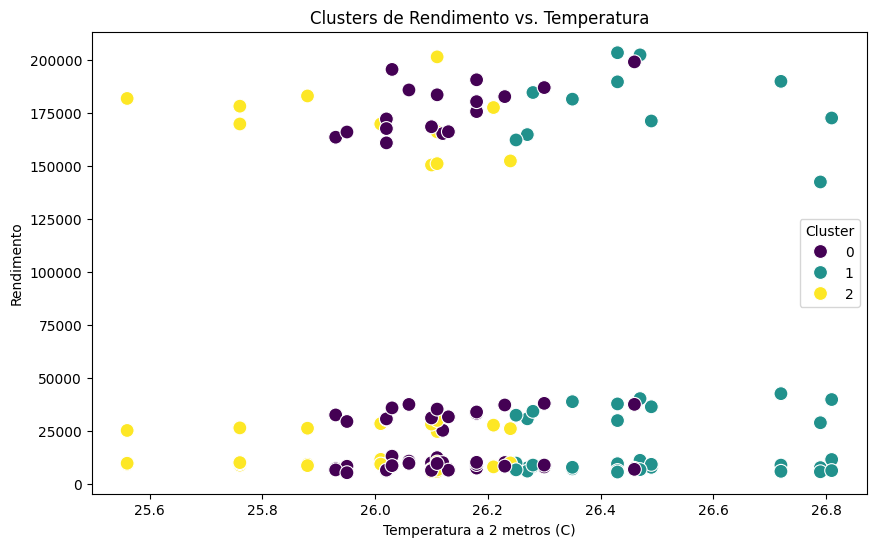

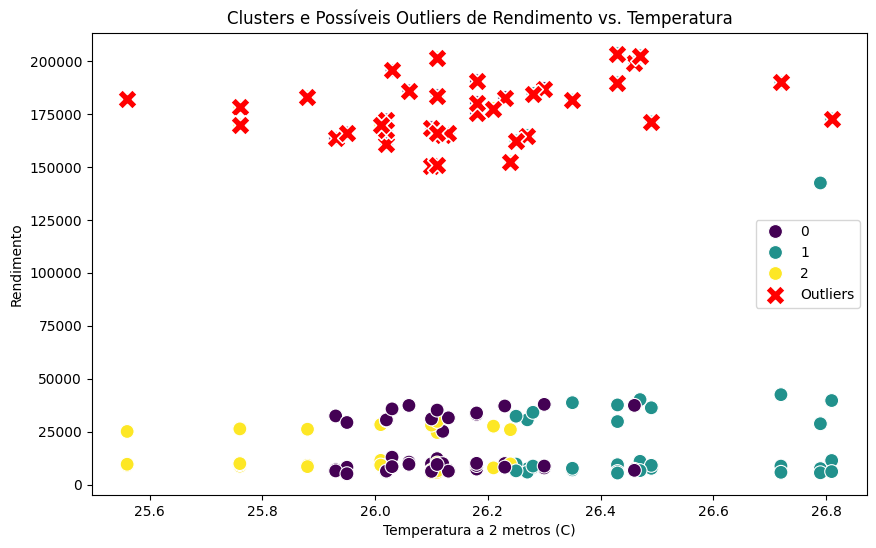

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Com base nos gráficos do Método Elbow e Coeficiente de Silhueta, vamos escolher um número de clusters.
# Por exemplo, vamos escolher 3 clusters.
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(X_processed)

# Adicionar os rótulos dos clusters ao DataFrame original
df['Cluster'] = kmeans.labels_

# Visualizar os clusters em um gráfico de dispersão (usando duas das variáveis numéricas para simplificar)
# Você pode escolher outras variáveis ou usar técnicas de redução de dimensionalidade como PCA para visualizar em 2D.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature at 2 Meters (C)', y='Yield', hue='Cluster', data=df, palette='viridis', s=100)
plt.title("Clusters de Rendimento vs. Temperatura")
plt.xlabel("Temperatura a 2 metros (C)")
plt.ylabel("Rendimento")
plt.show()

# Visualizar os outliers identificados em um gráfico de dispersão (opcional, pode ser sobreposto ao gráfico de clusters)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature at 2 Meters (C)', y='Yield', hue='Cluster', data=df, palette='viridis', s=100, label='Data')
sns.scatterplot(x='Temperature at 2 Meters (C)', y='Yield', data=outliers, color='red', s=200, marker='X', label='Outliers')
plt.title("Clusters e Possíveis Outliers de Rendimento vs. Temperatura")
plt.xlabel("Temperatura a 2 metros (C)")
plt.ylabel("Rendimento")
plt.legend()
plt.show()

# Você pode repetir a visualização para outros pares de variáveis numéricas ou usar PCA/t-SNE para visualização em 2D/3D.

## Análise de Outliers

Identificar cenários discrepantes (outliers) utilizando os resultados da clusterização.

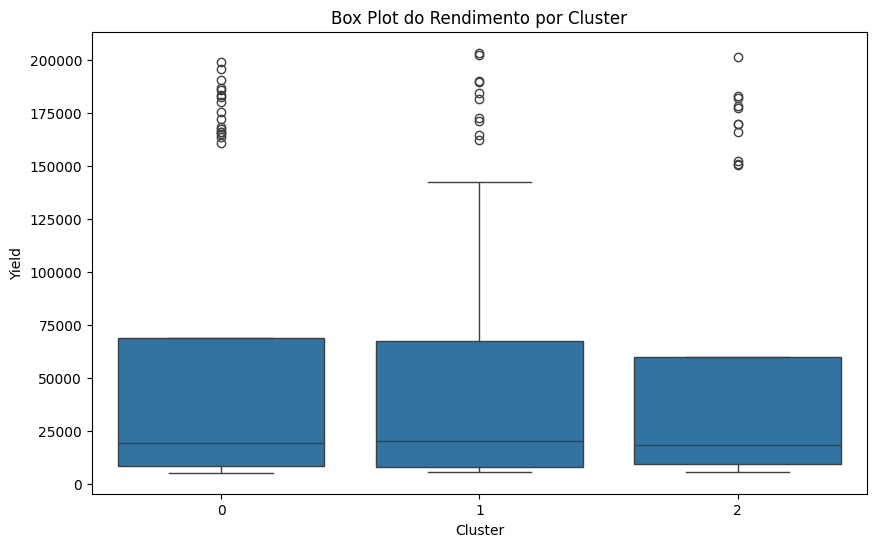


Possíveis Outliers identificados (baseado no IQR do Yield por cluster):


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,Cluster
46,Oil palm fruit,2718.08,18.30,85.43,26.12,165262,0
51,Oil palm fruit,2530.96,18.15,85.33,26.02,172165,0
52,Oil palm fruit,2504.70,18.19,85.45,26.02,160862,0
53,Oil palm fruit,2686.20,18.38,85.77,26.13,166136,0
54,Oil palm fruit,2414.79,18.18,85.76,25.93,163541,0
57,Oil palm fruit,2792.95,18.24,86.04,25.95,165993,0
58,Oil palm fruit,2751.24,18.31,85.98,26.02,167621,0
59,Oil palm fruit,2646.28,18.40,86.02,26.10,168476,0
61,Oil palm fruit,2692.34,18.37,85.54,26.18,175629,0
62,Oil palm fruit,2424.55,18.28,85.16,26.18,180323,0


In [10]:
# Calcular a distância de cada ponto ao centroide do seu cluster
# centroids = kmeans.cluster_centers_
# distances = np.sum((X_processed - centroids[kmeans.labels_])**2, axis=1)

# Uma maneira simples de identificar outliers dentro de cada cluster é olhar para pontos que estão
# a uma certa distância (por exemplo, usando o IQR) do centroide do cluster.
# Outra abordagem é usar métodos como Isolation Forest ou Local Outlier Factor (LOF).
# Para este exemplo, vamos usar uma abordagem baseada na distância ao centroide,
# mas focando na dispersão do Yield dentro de cada cluster.

# Analisar a distribuição do Yield dentro de cada cluster
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Yield', data=df)
plt.title("Box Plot do Rendimento por Cluster")
plt.show()

# Identificar outliers com base no IQR dentro de cada cluster para a variável 'Yield'
outliers = pd.DataFrame()
for cluster in range(n_clusters):
    cluster_df = df[df['Cluster'] == cluster]['Yield']
    Q1 = cluster_df.quantile(0.25)
    Q3 = cluster_df.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    cluster_outliers = df[(df['Cluster'] == cluster) & ((df['Yield'] < lower_bound) | (df['Yield'] > upper_bound))]
    outliers = pd.concat([outliers, cluster_outliers])

print("\nPossíveis Outliers identificados (baseado no IQR do Yield por cluster):")
display(outliers)

## Clusterização

Aplicar um algoritmo de clusterização para identificar grupos ou tendências nos rendimentos das plantações.

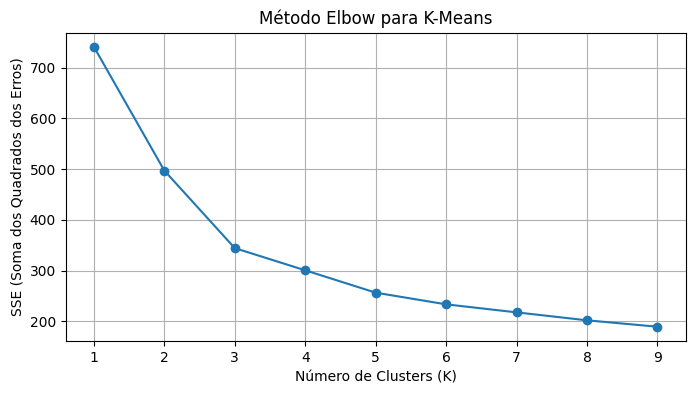

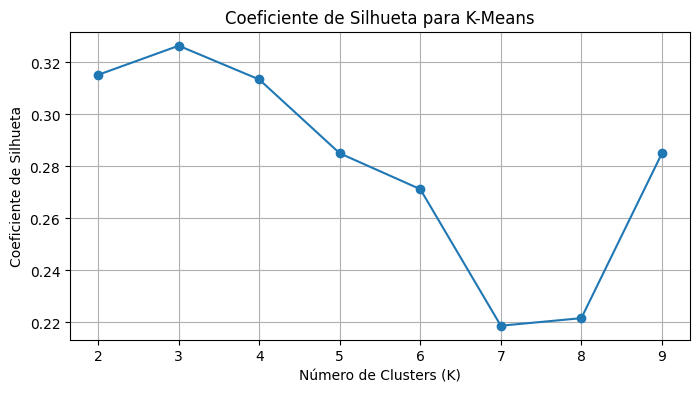

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Para determinar o número ideal de clusters, podemos usar o método Elbow ou o coeficiente de silhueta.
# Vamos usar o método Elbow primeiro.
sse = []
k_range = range(1, 10) # Testando de 1 a 9 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Adicionado n_init
    kmeans.fit(X_processed)
    sse.append(kmeans.inertia_)

# Plotar o método Elbow
plt.figure(figsize=(8, 4))
plt.plot(k_range, sse, marker='o')
plt.title('Método Elbow para K-Means')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('SSE (Soma dos Quadrados dos Erros)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Agora vamos calcular o coeficiente de silhueta para diferentes números de clusters (precisa de pelo menos 2 clusters)
silhouette_scores = []
k_range_silhouette = range(2, 10) # Precisa de pelo menos 2 clusters

for k in k_range_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Adicionado n_init
    kmeans.fit(X_processed)
    score = silhouette_score(X_processed, kmeans.labels_)
    silhouette_scores.append(score)

# Plotar o coeficiente de silhueta
plt.figure(figsize=(8, 4))
plt.plot(k_range_silhouette, silhouette_scores, marker='o')
plt.title('Coeficiente de Silhueta para K-Means')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Coeficiente de Silhueta')
plt.xticks(k_range_silhouette)
plt.grid(True)
plt.show()

## Análise Exploratória de Dados (AED)

Realizar visualizações para entender a distribuição das variáveis e identificar padrões.

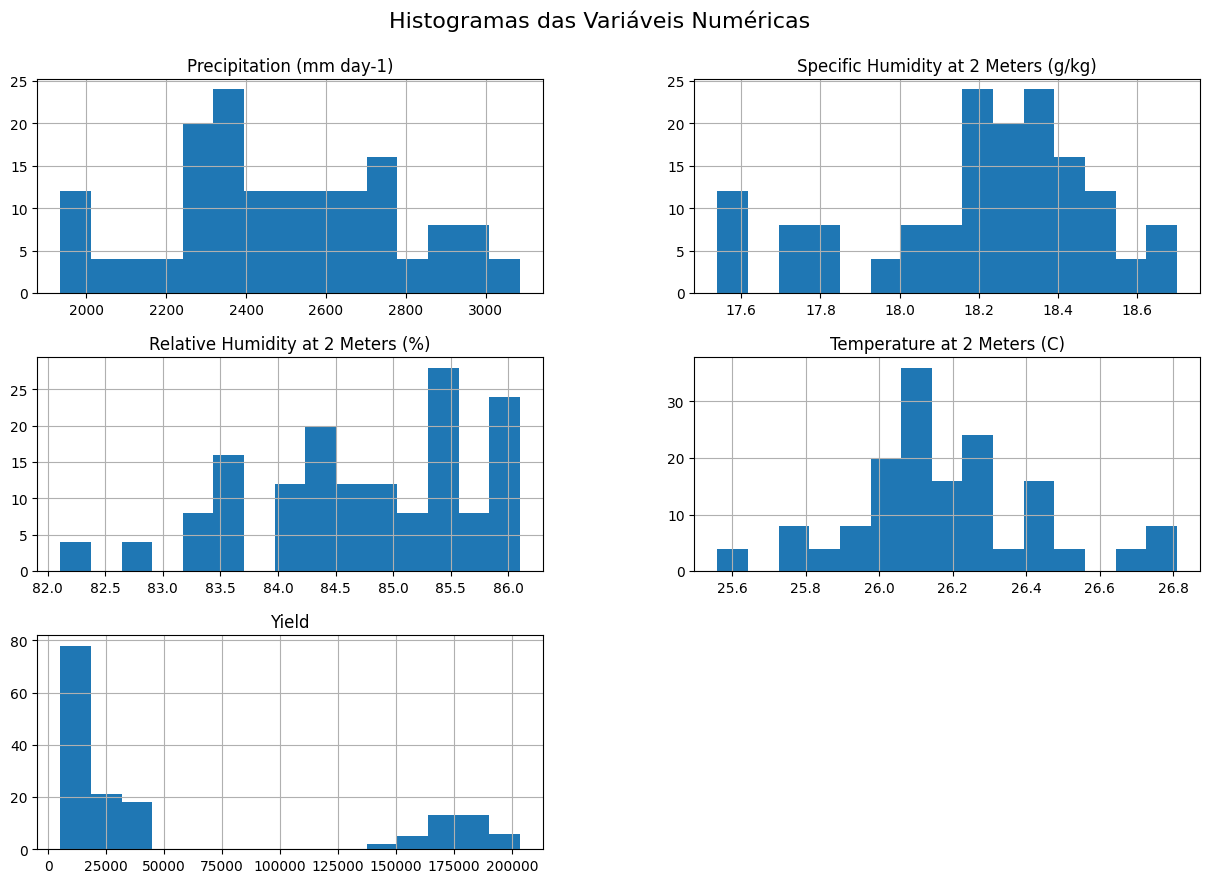

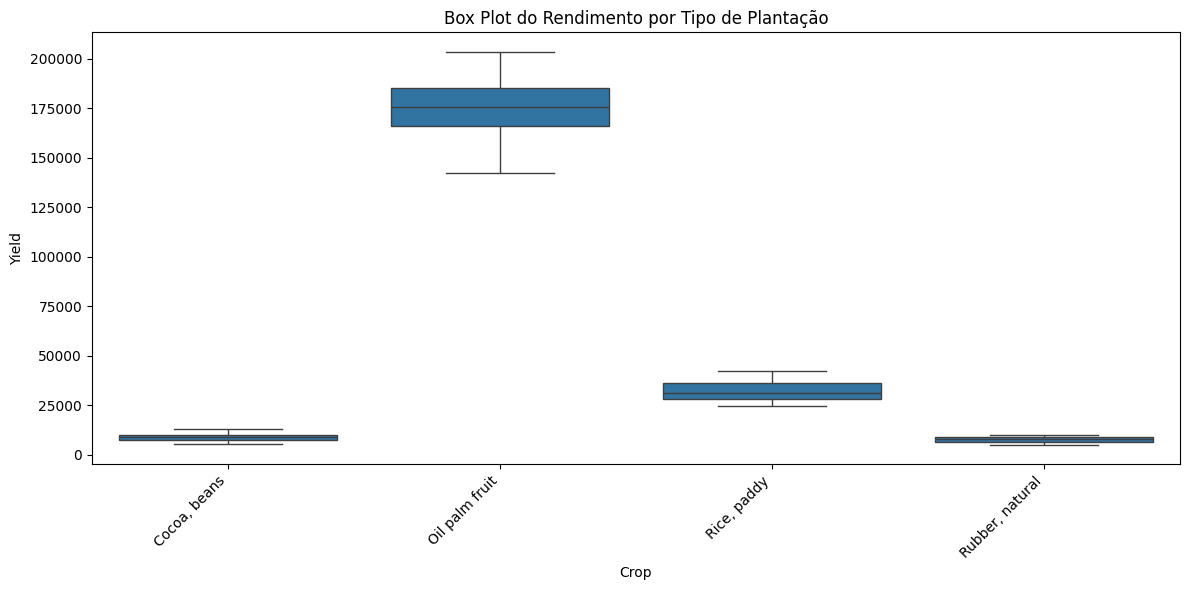

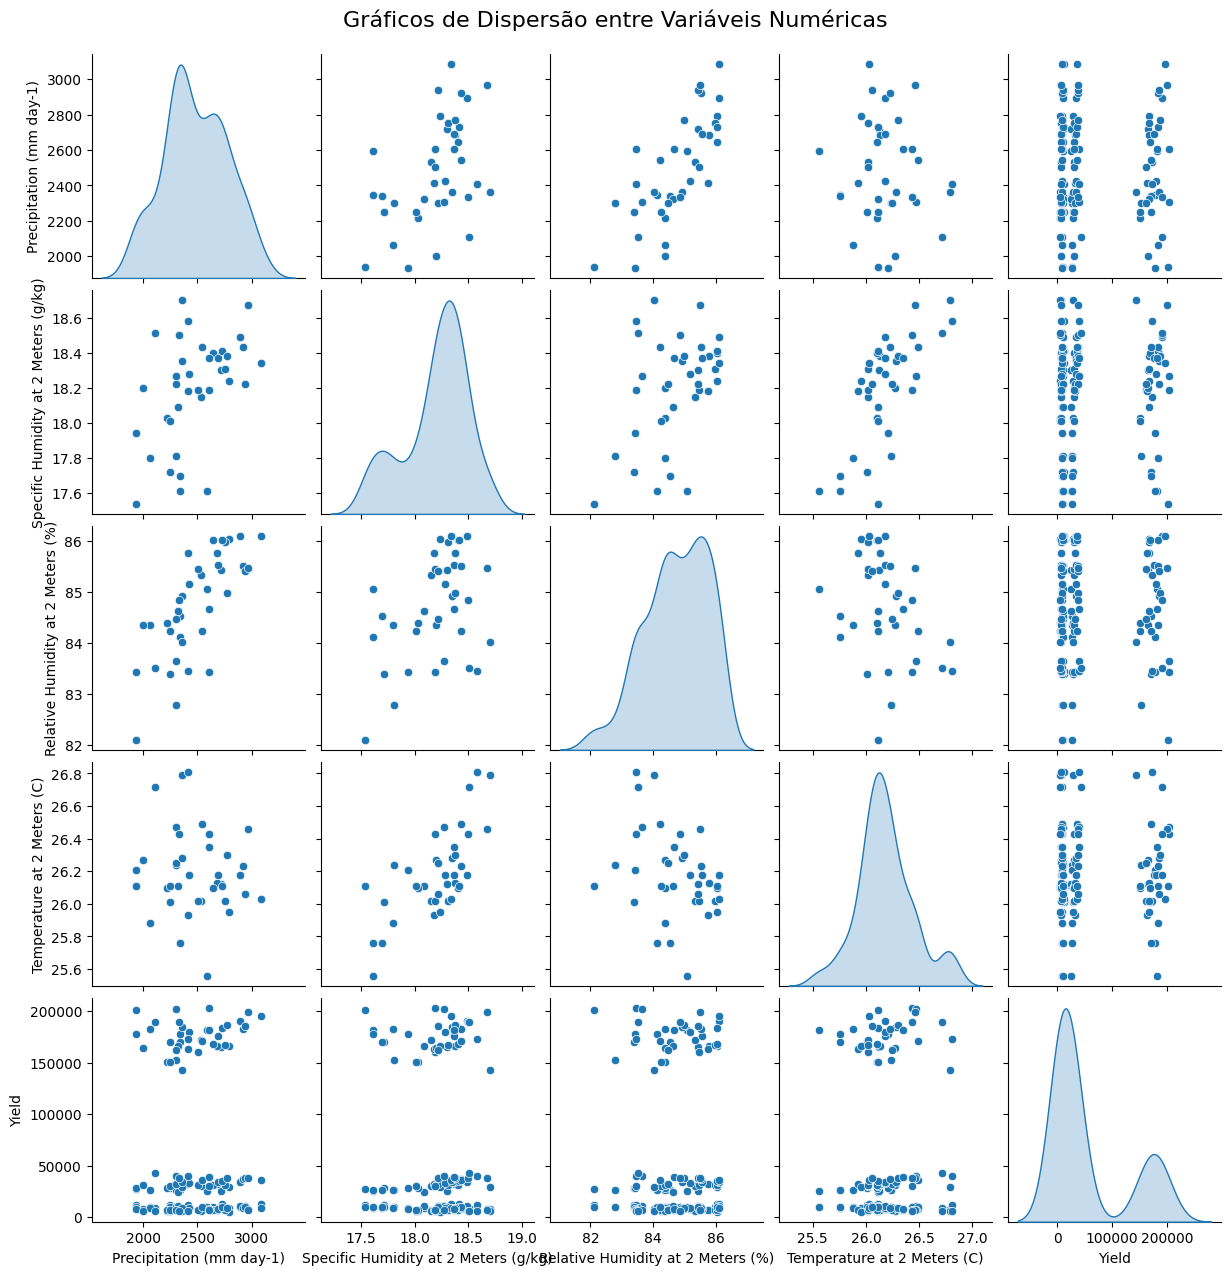

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma das variáveis numéricas
df.hist(bins=15, figsize=(15, 10))
plt.suptitle("Histogramas das Variáveis Numéricas", y=0.95, fontsize=16)
plt.show()

# Box plot do Yield por tipo de Crop
plt.figure(figsize=(12, 6))
sns.boxplot(x='Crop', y='Yield', data=df)
plt.title("Box Plot do Rendimento por Tipo de Plantação")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Gráfico de dispersão entre pares de variáveis numéricas
sns.pairplot(df, diag_kind='kde')
plt.suptitle("Gráficos de Dispersão entre Variáveis Numéricas", y=1.02, fontsize=16)
plt.show()

## Interpretação e Resumo

Com base nas análises realizadas, podemos observar o seguinte:

*   **Clusterização**: O método Elbow e o Coeficiente de Silhueta sugeriram 3 ou 4 clusters como um número razoável. Ao aplicar o K-Means com 3 clusters e visualizar os resultados, podemos ver como os dados são agrupados, principalmente em relação ao 'Yield' (Rendimento). Os box plots do 'Yield' por cluster também mostram a distribuição do rendimento dentro de cada grupo.

*   **Outliers**: A análise de outliers baseada no Intervalo Interquartil (IQR) dentro de cada cluster para a variável 'Yield' identificou pontos de dados que se desviam significativamente da distribuição da maioria dos pontos em seu cluster. A visualização desses outliers sobreposta ao gráfico de clusters ajuda a identificar visualmente esses pontos discrepantes.

*   **Tendências**: Ao analisar os clusters e as características das plantações dentro de cada cluster (embora a visualização tenha sido simplificada para duas variáveis), podemos começar a identificar tendências de rendimento relacionadas a diferentes tipos de plantações e condições ambientais. Por exemplo, um cluster pode corresponder a plantações com alto rendimento e determinadas condições climáticas, enquanto outro pode representar plantações com menor rendimento e condições diferentes.

*   **Cenários Discrepantes**: Os outliers identificados podem representar cenários atípicos, como rendimentos excepcionalmente altos ou baixos para um determinado tipo de plantação e conjunto de condições ambientais. A investigação desses outliers pode revelar informações importantes sobre fatores que influenciam o rendimento de forma incomum.

Para uma análise mais aprofundada, seria interessante:

*   Examinar as características das plantações e as condições ambientais dentro de cada cluster para entender melhor o que define cada grupo.
*   Investigar os outliers identificados para entender por que esses pontos são discrepantes. Isso pode envolver a verificação dos dados brutos ou a busca por fatores externos que possam ter influenciado o rendimento.
*   Considerar a repetição da análise de clusterização com um número diferente de clusters (por exemplo, 4) para ver se isso revela novas percepções.

Em resumo, a clusterização nos ajudou a agrupar as plantações com base em suas características e rendimentos, enquanto a análise de outliers destacou cenários que merecem investigação adicional. Essas descobertas fornecem um ponto de partida para entender as tendências de rendimento e identificar fatores que podem influenciar a produção das plantações.